MAE(PDF) = 11.76  |  MAE(CDF) = 58.82
Vérité: 100% à 14.0 mm ; Prédite: 100% à 0.05 mm


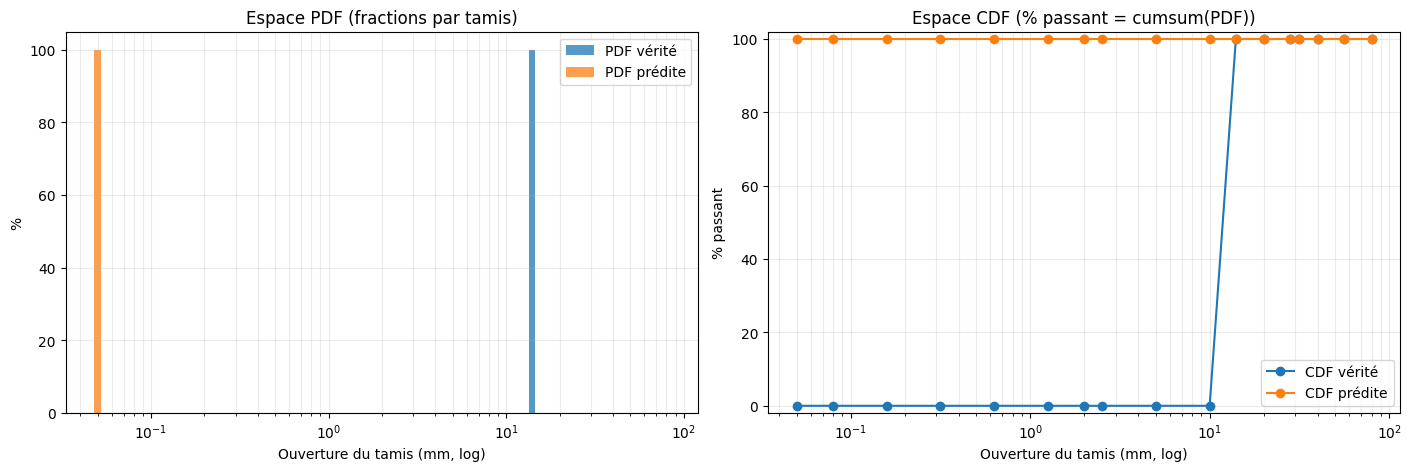

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tamis (fin -> gros), tel que fourni ---
PSD_COLUMNS = {
    "%_0.05mm": 0.05,
    "%_0.08mm": 0.08,
    "%_0.16mm": 0.16,
    "%_0.315mm": 0.315,
    "%_0.63mm": 0.63,
    "%_1.25mm": 1.25,
    "%_2mm": 2.0,
    "%_2.5mm": 2.5,
    "%_5mm": 5.0,
    "%_10mm": 10.0,
    "%_14mm": 14.0,
    "%_20mm": 20.0,
    "%_28mm": 28.0,
    "%_31.5mm": 31.5,
    "%_40mm": 40.0,
    "%_56mm": 56.0,
    "%_80mm": 80.0,
}

sieve_cols = list(PSD_COLUMNS.keys())                 # déjà fin -> gros
sieve_mm   = np.array(list(PSD_COLUMNS.values()), float)
n = len(sieve_mm)

def cdf_passing_from_pdf(pdf_percent):
    # fin -> gros => % passant croissant = cumsum(pdf)
    return np.cumsum(np.asarray(pdf_percent, dtype=float))

def mae(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    return np.mean(np.abs(a-b))

# -------------------------
# Exemple EXTREME (pas réaliste, mais démonstratif)
# Vérité: 100% de masse autour de 14 mm
# Prédiction: 100% de masse à 0.05 mm
# -------------------------
pdf_true = np.zeros(n)
pdf_pred = np.zeros(n)

idx_true = np.argmin(np.abs(sieve_mm - 14.0))
idx_pred = np.argmin(np.abs(sieve_mm - 0.05))

pdf_true[idx_true] = 100.0
pdf_pred[idx_pred] = 100.0

cdf_true = cdf_passing_from_pdf(pdf_true)
cdf_pred = cdf_passing_from_pdf(pdf_pred)

mae_pdf = mae(pdf_pred, pdf_true)
mae_cdf = mae(cdf_pred, cdf_true)

print(f"MAE(PDF) = {mae_pdf:.2f}  |  MAE(CDF) = {mae_cdf:.2f}")
print(f"Vérité: 100% à {sieve_mm[idx_true]} mm ; Prédite: 100% à {sieve_mm[idx_pred]} mm")

# -------------------------
# Graphiques (sans inversion de l'axe X)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)

# PDF
axes[0].bar(sieve_mm, pdf_true, width=sieve_mm*0.08, alpha=0.75, label="PDF vérité")
axes[0].bar(sieve_mm, pdf_pred, width=sieve_mm*0.08, alpha=0.75, label="PDF prédite")
axes[0].set_xscale("log")
axes[0].set_title("Espace PDF (fractions par tamis)")
axes[0].set_xlabel("Ouverture du tamis (mm, log)")
axes[0].set_ylabel("%")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

# CDF
axes[1].plot(sieve_mm, cdf_true, marker="o", label="CDF vérité")
axes[1].plot(sieve_mm, cdf_pred, marker="o", label="CDF prédite")
axes[1].set_xscale("log")
axes[1].set_ylim(-2, 102)
axes[1].set_title("Espace CDF (% passant = cumsum(PDF))")
axes[1].set_xlabel("Ouverture du tamis (mm, log)")
axes[1].set_ylabel("% passant")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()

plt.show()

Bins vérité : [(2.5, 20.0), (5.0, 50.0), (10.0, 30.0)]
Bins prédite: [(0.16, 20.0), (0.315, 50.0), (0.63, 30.0)]
MAE(PDF) = 11.76  |  MAE(CDF) = 29.41


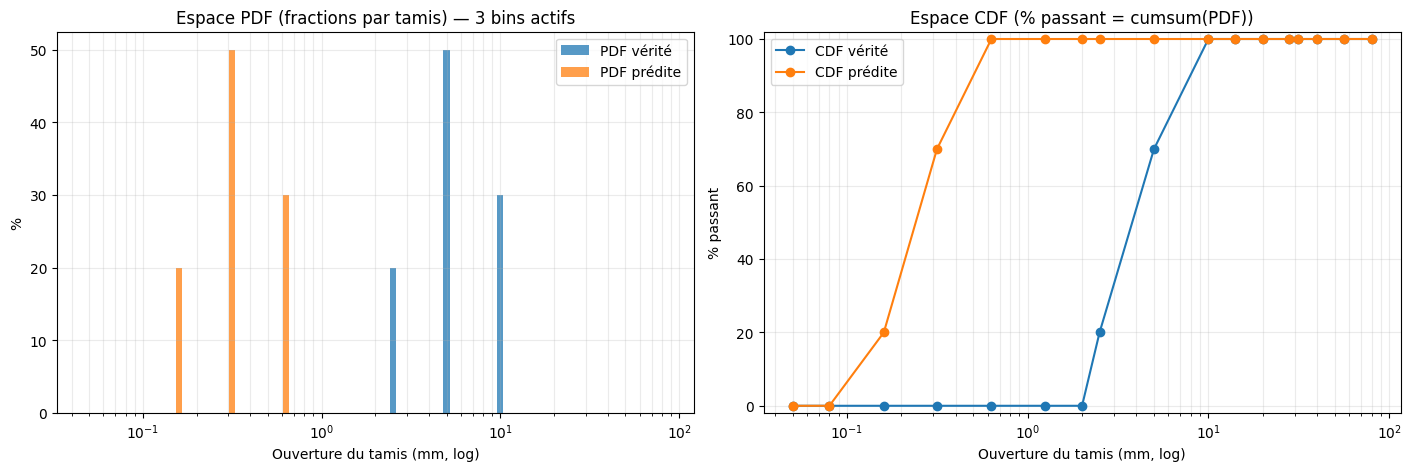

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tamis (fin -> gros), tel que fourni ---
PSD_COLUMNS = {
    "%_0.05mm": 0.05,
    "%_0.08mm": 0.08,
    "%_0.16mm": 0.16,
    "%_0.315mm": 0.315,
    "%_0.63mm": 0.63,
    "%_1.25mm": 1.25,
    "%_2mm": 2.0,
    "%_2.5mm": 2.5,
    "%_5mm": 5.0,
    "%_10mm": 10.0,
    "%_14mm": 14.0,
    "%_20mm": 20.0,
    "%_28mm": 28.0,
    "%_31.5mm": 31.5,
    "%_40mm": 40.0,
    "%_56mm": 56.0,
    "%_80mm": 80.0,
}

sieve_mm = np.array(list(PSD_COLUMNS.values()), float)
n = len(sieve_mm)

def cdf_passing_from_pdf(pdf_percent):
    # fin -> gros => % passant croissant = cumsum(pdf)
    return np.cumsum(np.asarray(pdf_percent, dtype=float))

def mae(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    return np.mean(np.abs(a-b))

def idx(mm):
    return int(np.argmin(np.abs(sieve_mm - mm)))

# -------------------------
# Exemple "moins extrême", peu de tamis actifs (3 bins)
# -------------------------
pdf_true = np.zeros(n)
pdf_pred = np.zeros(n)

# Vérité (3 bins actifs, total 100)
true_bins = [(2.5, 20.0), (5.0, 50.0), (10.0, 30.0)]
for mm, w in true_bins:
    pdf_true[idx(mm)] += w

# Prédiction (3 bins actifs, total 100) - même masses mais "trop fines"
pred_bins = [(0.16, 20.0), (0.315, 50.0), (0.63, 30.0)]
for mm, w in pred_bins:
    pdf_pred[idx(mm)] += w

cdf_true = cdf_passing_from_pdf(pdf_true)
cdf_pred = cdf_passing_from_pdf(pdf_pred)

mae_pdf = mae(pdf_pred, pdf_true)
mae_cdf = mae(cdf_pred, cdf_true)

print("Bins vérité :", true_bins)
print("Bins prédite:", pred_bins)
print(f"MAE(PDF) = {mae_pdf:.2f}  |  MAE(CDF) = {mae_cdf:.2f}")

# -------------------------
# Graphiques
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)

# PDF
axes[0].bar(sieve_mm, pdf_true, width=sieve_mm*0.08, alpha=0.75, label="PDF vérité")
axes[0].bar(sieve_mm, pdf_pred, width=sieve_mm*0.08, alpha=0.75, label="PDF prédite")
axes[0].set_xscale("log")
axes[0].set_title("Espace PDF (fractions par tamis) — 3 bins actifs")
axes[0].set_xlabel("Ouverture du tamis (mm, log)")
axes[0].set_ylabel("%")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

# CDF
axes[1].plot(sieve_mm, cdf_true, marker="o", label="CDF vérité")
axes[1].plot(sieve_mm, cdf_pred, marker="o", label="CDF prédite")
axes[1].set_xscale("log")
axes[1].set_ylim(-2, 102)
axes[1].set_title("Espace CDF (% passant = cumsum(PDF))")
axes[1].set_xlabel("Ouverture du tamis (mm, log)")
axes[1].set_ylabel("% passant")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()

plt.show()

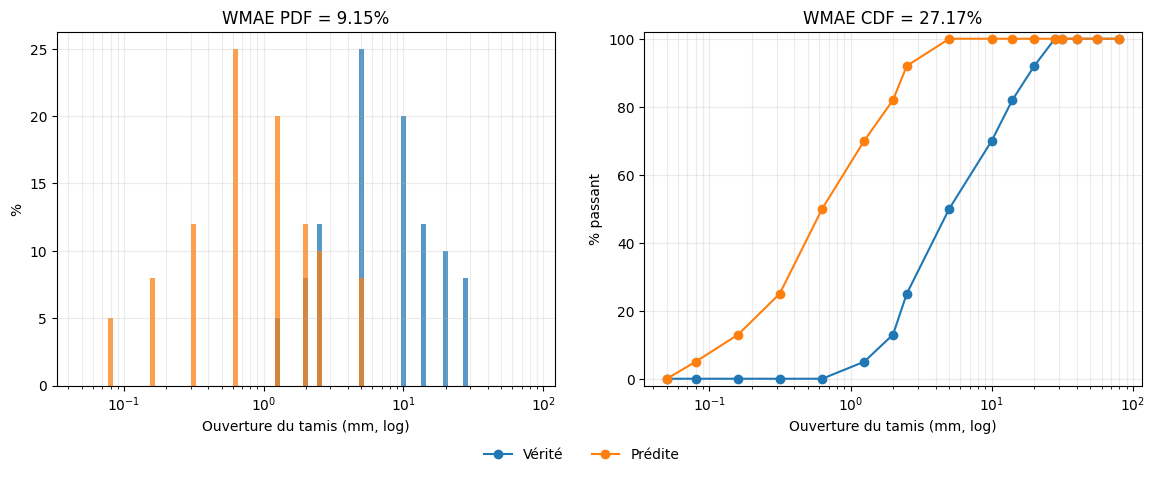

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tamis (fin -> gros), tel que fourni ---
PSD_COLUMNS = {
    "%_0.05mm": 0.05,
    "%_0.08mm": 0.08,
    "%_0.16mm": 0.16,
    "%_0.315mm": 0.315,
    "%_0.63mm": 0.63,
    "%_1.25mm": 1.25,
    "%_2mm": 2.0,
    "%_2.5mm": 2.5,
    "%_5mm": 5.0,
    "%_10mm": 10.0,
    "%_14mm": 14.0,
    "%_20mm": 20.0,
    "%_28mm": 28.0,
    "%_31.5mm": 31.5,
    "%_40mm": 40.0,
    "%_56mm": 56.0,
    "%_80mm": 80.0,
}
sieve_mm = np.array(list(PSD_COLUMNS.values()), float)
n = len(sieve_mm)

def cdf_passing_from_pdf(pdf_percent):
    return np.cumsum(np.asarray(pdf_percent, dtype=float))

def _infer_bin_spacing(bin_x):
    bin_x = np.asarray(bin_x, dtype=float)
    if bin_x.ndim != 1:
        raise ValueError("bin_x must be 1D")
    if bin_x.size == 0:
        return np.array([], dtype=float)
    if bin_x.size == 1:
        return np.array([1.0], dtype=float)
    diffs = np.diff(bin_x)
    last = float(diffs[-1]) if diffs.size else 1.0
    return np.concatenate([diffs, [last]])

def wmae(a, b, bin_x):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    spacing = _infer_bin_spacing(bin_x)
    weights = spacing / float(np.sum(spacing))
    return float(np.sum(np.abs(a - b) * weights))

def idx(mm):
    return int(np.argmin(np.abs(sieve_mm - mm)))

# -------------------------
# Exemple (volontairement faux): prédiction trop fine
# -------------------------
pdf_true = np.zeros(n)
pdf_pred = np.zeros(n)

true_bins = [
    (1.25, 5.0),
    (2.0,  8.0),
    (2.5, 12.0),
    (5.0,  25.0),
    (10.0, 20.0),
    (14.0, 12.0),
    (20.0, 10.0),
    (28.0, 8.0),
]
pred_bins = [
    (0.08, 5.0),
    (0.16, 8.0),
    (0.315,12.0),
    (0.63, 25.0),
    (1.25, 20.0),
    (2.0,  12.0),
    (2.5,  10.0),
    (5.0,  8.0),
]

for mm, w in true_bins:
    pdf_true[idx(mm)] += w
for mm, w in pred_bins:
    pdf_pred[idx(mm)] += w

cdf_true = cdf_passing_from_pdf(pdf_true)
cdf_pred = cdf_passing_from_pdf(pdf_pred)

# Pondération cohérente avec ton pipeline (bin_x_log10)
bin_x_log10 = np.log10(sieve_mm)

wmae_pdf = wmae(pdf_pred, pdf_true, bin_x_log10)
wmae_cdf = wmae(cdf_pred, cdf_true, bin_x_log10)

# -------------------------
# Graphiques (une seule légende en bas)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=False)
fig.subplots_adjust(bottom=0.20, wspace=0.18)

# PDF
axes[0].bar(sieve_mm, pdf_true, width=sieve_mm*0.08, alpha=0.75, label="Vérité")
axes[0].bar(sieve_mm, pdf_pred, width=sieve_mm*0.08, alpha=0.75, label="Prédite")
axes[0].set_xscale("log")
axes[0].set_title(f"WMAE PDF = {wmae_pdf:.2f}%")
axes[0].set_xlabel("Ouverture du tamis (mm, log)")
axes[0].set_ylabel("%")
axes[0].grid(True, which="both", alpha=0.25)

# CDF
l1, = axes[1].plot(sieve_mm, cdf_true, marker="o", label="Vérité")
l2, = axes[1].plot(sieve_mm, cdf_pred, marker="o", label="Prédite")
axes[1].set_xscale("log")
axes[1].set_ylim(-2, 102)
axes[1].set_title(f"WMAE CDF = {wmae_cdf:.2f}%")
axes[1].set_xlabel("Ouverture du tamis (mm, log)")
axes[1].set_ylabel("% passant")
axes[1].grid(True, which="both", alpha=0.25)

# Une seule légende globale (bas, centré) avec 2 entrées
handles = [l1, l2]
labels = ["Vérité", "Prédite"]
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.03))

plt.show()

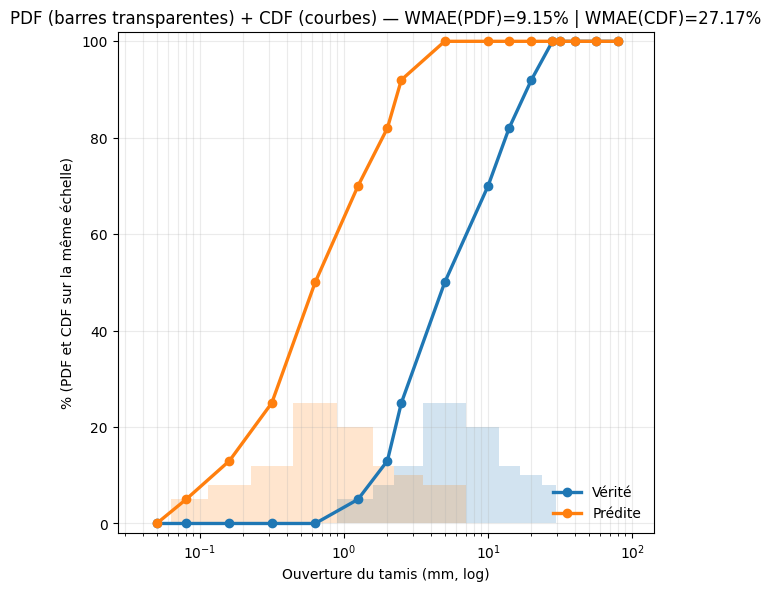

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tamis (fin -> gros), tel que fourni ---
PSD_COLUMNS = {
    "%_0.05mm": 0.05,
    "%_0.08mm": 0.08,
    "%_0.16mm": 0.16,
    "%_0.315mm": 0.315,
    "%_0.63mm": 0.63,
    "%_1.25mm": 1.25,
    "%_2mm": 2.0,
    "%_2.5mm": 2.5,
    "%_5mm": 5.0,
    "%_10mm": 10.0,
    "%_14mm": 14.0,
    "%_20mm": 20.0,
    "%_28mm": 28.0,
    "%_31.5mm": 31.5,
    "%_40mm": 40.0,
    "%_56mm": 56.0,
    "%_80mm": 80.0,
}
sieve_mm = np.array(list(PSD_COLUMNS.values()), float)
n = len(sieve_mm)

def cdf_passing_from_pdf(pdf_percent):
    return np.cumsum(np.asarray(pdf_percent, dtype=float))

def _infer_bin_spacing(bin_x):
    bin_x = np.asarray(bin_x, dtype=float)
    if bin_x.ndim != 1:
        raise ValueError("bin_x must be 1D")
    if bin_x.size == 0:
        return np.array([], dtype=float)
    if bin_x.size == 1:
        return np.array([1.0], dtype=float)
    diffs = np.diff(bin_x)
    last = float(diffs[-1]) if diffs.size else 1.0
    return np.concatenate([diffs, [last]])

def wmae(a, b, bin_x):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    spacing = _infer_bin_spacing(bin_x)
    weights = spacing / float(np.sum(spacing))
    return float(np.sum(np.abs(a - b) * weights))

def idx(mm):
    return int(np.argmin(np.abs(sieve_mm - mm)))

# -------------------------
# Exemple (volontairement faux): prédiction trop fine
# -------------------------
pdf_true = np.zeros(n)
pdf_pred = np.zeros(n)

true_bins = [
    (1.25, 5.0),
    (2.0,  8.0),
    (2.5, 12.0),
    (5.0,  25.0),
    (10.0, 20.0),
    (14.0, 12.0),
    (20.0, 10.0),
    (28.0, 8.0),
]
pred_bins = [
    (0.08, 5.0),
    (0.16, 8.0),
    (0.315,12.0),
    (0.63, 25.0),
    (1.25, 20.0),
    (2.0,  12.0),
    (2.5,  10.0),
    (5.0,  8.0),
]

for mm, w in true_bins:
    pdf_true[idx(mm)] += w
for mm, w in pred_bins:
    pdf_pred[idx(mm)] += w

cdf_true = cdf_passing_from_pdf(pdf_true)
cdf_pred = cdf_passing_from_pdf(pdf_pred)

# Pondération cohérente avec ton pipeline (bin_x_log10)
bin_x_log10 = np.log10(sieve_mm)
wmae_pdf = wmae(pdf_pred, pdf_true, bin_x_log10)
wmae_cdf = wmae(cdf_pred, cdf_true, bin_x_log10)

# -------------------------
# Un seul axe Y (0..100) pour tout: on superpose PDF et CDF sur la même échelle
# + bins "larges" pour la PDF (largeur basée sur les frontières entre tamis)
# -------------------------

# Largeurs "visuelles" des bins (en mm) sur un axe log:
# on construit des bords en log10 (midpoints), puis on convertit en mm
logx = np.log10(sieve_mm)
edges_log = np.empty(n + 1)
edges_log[1:-1] = (logx[:-1] + logx[1:]) / 2.0
edges_log[0] = logx[0] - (logx[1] - logx[0]) / 2.0
edges_log[-1] = logx[-1] + (logx[-1] - logx[-2]) / 2.0
edges_mm = 10 ** edges_log
width_mm = edges_mm[1:] - edges_mm[:-1]

fig, ax = plt.subplots(figsize=(6, 5.8), constrained_layout=True)

# PDF en arrière-plan (transparent, bins larges)
# (align='edge' pour que la barre commence au bord gauche du bin)
ax.bar(edges_mm[:-1], pdf_true, width=width_mm, align="edge",
       alpha=0.20, color="tab:blue", edgecolor="none", label="PDF vérité")
ax.bar(edges_mm[:-1], pdf_pred, width=width_mm, align="edge",
       alpha=0.20, color="tab:orange", edgecolor="none", label="PDF prédite")

# CDF par-dessus (courbes)
l1, = ax.plot(sieve_mm, cdf_true, marker="o", linewidth=2.4, color="tab:blue", label="CDF vérité")
l2, = ax.plot(sieve_mm, cdf_pred, marker="o", linewidth=2.4, color="tab:orange", label="CDF prédite")

ax.set_xscale("log")
ax.set_ylim(-2, 102)
ax.set_xlabel("Ouverture du tamis (mm, log)")
ax.set_ylabel("% (PDF et CDF sur la même échelle)")
ax.grid(True, which="both", alpha=0.25)

ax.set_title(f"PDF (barres transparentes) + CDF (courbes) — WMAE(PDF)={wmae_pdf:.2f}% | WMAE(CDF)={wmae_cdf:.2f}%")

# Légende unique (on ne garde que 2 entrées: Vérité/Prédite)
# -> on utilise les lignes (CDF) pour la légende; les barres restent implicites
ax.legend(handles=[l1, l2], labels=["Vérité", "Prédite"], loc="lower right", frameon=False)

plt.show()

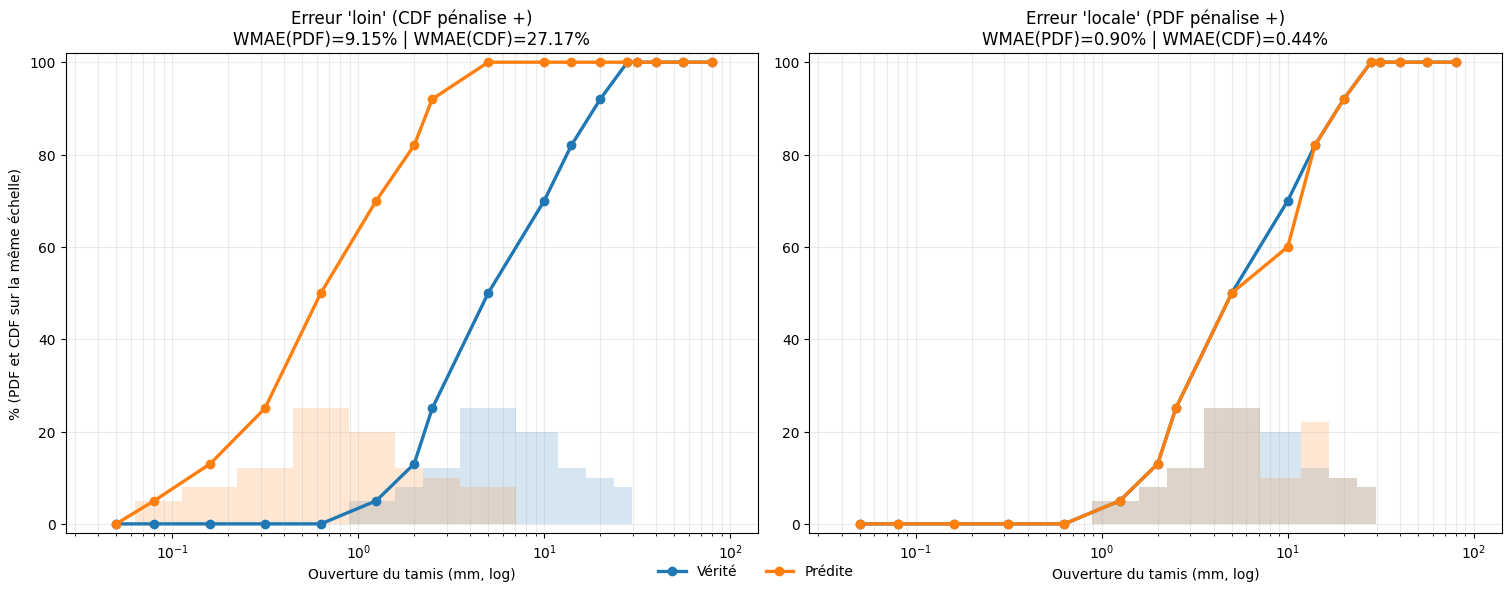

Cas A (loin):   WMAE(PDF) = 9.1488  | WMAE(CDF) = 27.1657
Cas B (local):  WMAE(PDF) = 0.8962  | WMAE(CDF) = 0.435


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tamis (fin -> gros), tel que fourni ---
PSD_COLUMNS = {
    "%_0.05mm": 0.05,
    "%_0.08mm": 0.08,
    "%_0.16mm": 0.16,
    "%_0.315mm": 0.315,
    "%_0.63mm": 0.63,
    "%_1.25mm": 1.25,
    "%_2mm": 2.0,
    "%_2.5mm": 2.5,
    "%_5mm": 5.0,
    "%_10mm": 10.0,
    "%_14mm": 14.0,
    "%_20mm": 20.0,
    "%_28mm": 28.0,
    "%_31.5mm": 31.5,
    "%_40mm": 40.0,
    "%_56mm": 56.0,
    "%_80mm": 80.0,
}
sieve_mm = np.array(list(PSD_COLUMNS.values()), float)
n = len(sieve_mm)

def cdf_passing_from_pdf(pdf_percent):
    return np.cumsum(np.asarray(pdf_percent, dtype=float))

def _infer_bin_spacing(bin_x):
    bin_x = np.asarray(bin_x, dtype=float)
    if bin_x.ndim != 1:
        raise ValueError("bin_x must be 1D")
    if bin_x.size == 0:
        return np.array([], dtype=float)
    if bin_x.size == 1:
        return np.array([1.0], dtype=float)
    diffs = np.diff(bin_x)
    last = float(diffs[-1]) if diffs.size else 1.0
    return np.concatenate([diffs, [last]])

def wmae(a, b, bin_x):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    spacing = _infer_bin_spacing(bin_x)
    weights = spacing / float(np.sum(spacing))
    return float(np.sum(np.abs(a - b) * weights))

def idx(mm):
    return int(np.argmin(np.abs(sieve_mm - mm)))

def bin_edges_from_centers_log(centers_mm):
    """Construit des bords en log10 (midpoints), puis convertit en mm."""
    centers_mm = np.asarray(centers_mm, dtype=float)
    logx = np.log10(centers_mm)
    edges_log = np.empty(centers_mm.size + 1)
    edges_log[1:-1] = (logx[:-1] + logx[1:]) / 2.0
    edges_log[0] = logx[0] - (logx[1] - logx[0]) / 2.0
    edges_log[-1] = logx[-1] + (logx[-1] - logx[-2]) / 2.0
    edges_mm = 10 ** edges_log
    widths_mm = edges_mm[1:] - edges_mm[:-1]
    return edges_mm, widths_mm

# Pondération cohérente avec ton pipeline (bin_x_log10)
bin_x_log10 = np.log10(sieve_mm)

# ---------------------------------------------------------------------
# Vérité commune aux 2 graphes (même "forme" qu'avant, plusieurs bins actifs)
# ---------------------------------------------------------------------
pdf_true = np.zeros(n)
true_bins = [
    (1.25, 5.0),
    (2.0,  8.0),
    (2.5, 12.0),
    (5.0,  25.0),
    (10.0, 20.0),
    (14.0, 12.0),
    (20.0, 10.0),
    (28.0, 8.0),
]
for mm, w in true_bins:
    pdf_true[idx(mm)] += w
cdf_true = cdf_passing_from_pdf(pdf_true)

# ---------------------------------------------------------------------
# Cas A: erreur "loin" => typiquement WMAE(CDF) > WMAE(PDF)
# ---------------------------------------------------------------------
pdf_pred_far = np.zeros(n)
pred_far_bins = [
    (0.08, 5.0),
    (0.16, 8.0),
    (0.315,12.0),
    (0.63, 25.0),
    (1.25, 20.0),
    (2.0,  12.0),
    (2.5,  10.0),
    (5.0,  8.0),
]
for mm, w in pred_far_bins:
    pdf_pred_far[idx(mm)] += w
cdf_pred_far = cdf_passing_from_pdf(pdf_pred_far)

wmae_pdf_far = wmae(pdf_pred_far, pdf_true, bin_x_log10)
wmae_cdf_far = wmae(cdf_pred_far, cdf_true, bin_x_log10)

# ---------------------------------------------------------------------
# Cas B: erreur "locale" => souvent WMAE(PDF) > WMAE(CDF)
# (swap local: on déplace 10% de 10mm vers 14mm)
# ---------------------------------------------------------------------
pdf_pred_local = pdf_true.copy()
delta = 10.0
pdf_pred_local[idx(10.0)] -= delta
pdf_pred_local[idx(14.0)] += delta
cdf_pred_local = cdf_passing_from_pdf(pdf_pred_local)

wmae_pdf_local = wmae(pdf_pred_local, pdf_true, bin_x_log10)
wmae_cdf_local = wmae(cdf_pred_local, cdf_true, bin_x_log10)

# ---------------------------------------------------------------------
# Plot helper: un seul axe Y (0..100), PDF en barres transparentes + CDF en lignes
# ---------------------------------------------------------------------
edges_mm, widths_mm = bin_edges_from_centers_log(sieve_mm)

def plot_case(ax, pdf_pred, cdf_pred, title):
    # PDF (transparent, bins larges)
    ax.bar(edges_mm[:-1], pdf_true, width=widths_mm, align="edge",
           alpha=0.18, color="tab:blue", edgecolor="none")
    ax.bar(edges_mm[:-1], pdf_pred, width=widths_mm, align="edge",
           alpha=0.18, color="tab:orange", edgecolor="none")

    # CDF (courbes)
    l1, = ax.plot(sieve_mm, cdf_true, marker="o", linewidth=2.4, color="tab:blue", label="Vérité")
    l2, = ax.plot(sieve_mm, cdf_pred, marker="o", linewidth=2.4, color="tab:orange", label="Prédite")

    ax.set_xscale("log")
    ax.set_ylim(-2, 102)
    ax.set_xlabel("Ouverture du tamis (mm, log)")
    ax.grid(True, which="both", alpha=0.25)
    ax.set_title(title)
    return l1, l2

# ---------------------------------------------------------------------
# Figure côte-à-côte
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), constrained_layout=True)

l1, l2 = plot_case(
    axes[0],
    pdf_pred_far,
    cdf_pred_far,
    title=f"Erreur 'loin' (CDF pénalise +)\nWMAE(PDF)={wmae_pdf_far:.2f}% | WMAE(CDF)={wmae_cdf_far:.2f}%"
)
plot_case(
    axes[1],
    pdf_pred_local,
    cdf_pred_local,
    title=f"Erreur 'locale' (PDF pénalise +)\nWMAE(PDF)={wmae_pdf_local:.2f}% | WMAE(CDF)={wmae_cdf_local:.2f}%"
)

axes[0].set_ylabel("% (PDF et CDF sur la même échelle)")
axes[1].set_ylabel("")

# Légende unique
fig.legend([l1, l2], ["Vérité", "Prédite"], loc="lower center", ncol=2, frameon=False)

plt.show()

print("Cas A (loin):   WMAE(PDF) =", round(wmae_pdf_far, 4), " | WMAE(CDF) =", round(wmae_cdf_far, 4))
print("Cas B (local):  WMAE(PDF) =", round(wmae_pdf_local, 4), " | WMAE(CDF) =", round(wmae_cdf_local, 4))